### __Author__ : Diba Elahi
### Medical Appointments No Shows

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from torchvision import transforms
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import sklearn.metrics as metrics
import seaborn as sns
from sklearn.model_selection import KFold

/Users/diba/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/diba/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


## Data Preprocessing

In [101]:
df = pd.read_csv("KaggleV2-May-2016.csv")

In [102]:
df

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [103]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [104]:
df.isnull().sum() # We do not have null values. 

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [105]:
df.notnull().sum() 

PatientId         110527
AppointmentID     110527
Gender            110527
ScheduledDay      110527
AppointmentDay    110527
Age               110527
Neighbourhood     110527
Scholarship       110527
Hipertension      110527
Diabetes          110527
Alcoholism        110527
Handcap           110527
SMS_received      110527
No-show           110527
dtype: int64

In [106]:
df = df.drop(['PatientId'], axis=1)
df = df.drop(['AppointmentID'], axis=1)

In [107]:
ordinal_encoder1 = OrdinalEncoder()
ordinal_encoder2 = OrdinalEncoder() 
ordinal_encoder3 = OrdinalEncoder()
ordinal_encoder4 = OrdinalEncoder()
ordinal_encoder5 = OrdinalEncoder()
df = df.copy()
df['Gender'] = ordinal_encoder1.fit_transform(df['Gender'].values.reshape(-1, 1))
df['Neighbourhood'] = ordinal_encoder2.fit_transform(df['Neighbourhood'].values.reshape(-1, 1))
df['No-show'] = ordinal_encoder3.fit_transform(df['No-show'].values.reshape(-1, 1))
df['ScheduledDay'] = ordinal_encoder4.fit_transform(df['ScheduledDay'].values.reshape(-1, 1))
df['AppointmentDay'] = ordinal_encoder5.fit_transform(df['AppointmentDay'].values.reshape(-1, 1))

In [108]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,110527.0,0.350023,0.476979,0.0,0.0,0.0,1.0,1.0
ScheduledDay,110527.0,51807.962045,29761.232427,0.0,26117.0,51761.0,77538.5,103548.0
AppointmentDay,110527.0,13.258851,7.895066,0.0,6.0,14.0,20.0,26.0
Age,110527.0,37.088874,23.110205,-1.0,18.0,37.0,55.0,115.0
Neighbourhood,110527.0,41.737286,22.361634,0.0,26.0,40.0,60.0,80.0
Scholarship,110527.0,0.098266,0.297675,0.0,0.0,0.0,0.0,1.0
Hipertension,110527.0,0.197246,0.397921,0.0,0.0,0.0,0.0,1.0
Diabetes,110527.0,0.071865,0.258265,0.0,0.0,0.0,0.0,1.0
Alcoholism,110527.0,0.030400,0.171686,0.0,0.0,0.0,0.0,1.0
Handcap,110527.0,0.022248,0.161543,0.0,0.0,0.0,0.0,4.0


In [109]:
df

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,0.0,27741.0,0.0,62,39.0,0,1,0,0,0,0,0.0
1,1.0,27503.0,0.0,56,39.0,0,0,0,0,0,0,0.0
2,0.0,27538.0,0.0,62,45.0,0,0,0,0,0,0,0.0
3,0.0,27708.0,0.0,8,54.0,0,0,0,0,0,0,0.0
4,0.0,27497.0,0.0,56,39.0,0,1,1,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
110522,0.0,33182.0,25.0,56,43.0,0,0,0,0,0,1,0.0
110523,0.0,32187.0,25.0,51,43.0,0,0,0,0,0,1,0.0
110524,0.0,21536.0,25.0,21,43.0,0,0,0,0,0,1,0.0
110525,0.0,21399.0,25.0,38,43.0,0,0,0,0,0,1,0.0


In [110]:
data = df.values
data

array([[0.0000e+00, 2.7741e+04, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.0000e+00, 2.7503e+04, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [0.0000e+00, 2.7538e+04, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       ...,
       [0.0000e+00, 2.1536e+04, 2.5000e+01, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [0.0000e+00, 2.1399e+04, 2.5000e+01, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [0.0000e+00, 2.1019e+04, 2.5000e+01, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00]])

In [111]:
for i in range(data.shape[1]-1): # -1 to exclude the No-Show column
    data[:,i] = (data[:,i] - np.min(data[:,i])) / (np.max(data[:,i]) - np.min(data[:,i]))

In [112]:
df.loc[:,df.columns != 'No-show'] = data[:,:-1]

In [113]:
df

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,0.0,0.267905,0.000000,0.543103,0.4875,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.265606,0.000000,0.491379,0.4875,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.265944,0.000000,0.543103,0.5625,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.267586,0.000000,0.077586,0.6750,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.265548,0.000000,0.491379,0.4875,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
110522,0.0,0.320450,0.961538,0.491379,0.5375,0.0,0.0,0.0,0.0,0.0,1.0,0.0
110523,0.0,0.310841,0.961538,0.448276,0.5375,0.0,0.0,0.0,0.0,0.0,1.0,0.0
110524,0.0,0.207981,0.961538,0.189655,0.5375,0.0,0.0,0.0,0.0,0.0,1.0,0.0
110525,0.0,0.206658,0.961538,0.336207,0.5375,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [114]:
def outlier_removal(data):
    drop_outliers = np.array([])
    for col in data.columns:
        upper_bound = data[col].quantile(0.99)
        lower_bound = data[col].quantile(0.01)

        df = data[col]
        indices = df[(df < lower_bound) | (df > upper_bound)].index
        drop_outliers = np.append(drop_outliers, indices)
    return drop_outliers

In [115]:
cleaned_df = df.copy()
drop = outlier_removal(cleaned_df)
dropped = np.unique(drop)
cleaned_df.drop(dropped, inplace=True)
cleaned_df.shape

(106305, 12)

In [116]:
cleaned_df = cleaned_df.drop(['Gender'], axis=1)
cleaned_df = cleaned_df.drop(['Alcoholism'], axis=1)

In [117]:
X= cleaned_df.drop('No-show', axis=1)
y= cleaned_df['No-show']

In [118]:
x_train ,x_test ,y_train ,y_test = train_test_split(X, y ,random_state = 1 ,test_size = .20)

In [119]:
class data:
    def __init__(self, X, y, scale_data=False):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
        print(type(self.y))
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [120]:
transform = transforms.Compose([transforms.ToTensor(),  transforms.Normalize((0.5,), (0.5,))])
train_dataset = data(x_train.values, y_train.values, scale_data=False)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_dataset = data(x_test.values, y_test.values, scale_data=False)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=0)

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [121]:
data_iter = iter(trainloader)
features, labels = next(data_iter)

### Visualization

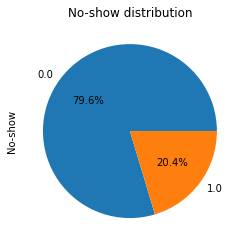

In [122]:
cleaned_df["No-show"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("No-show distribution");

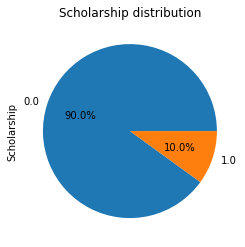

In [123]:
cleaned_df["Scholarship"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Scholarship distribution");

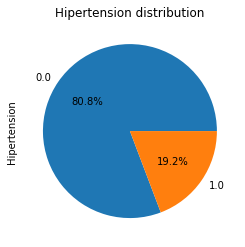

In [124]:
cleaned_df["Hipertension"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Hipertension distribution");

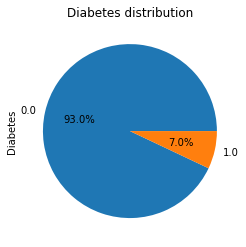

In [125]:
cleaned_df["Diabetes"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Diabetes distribution");

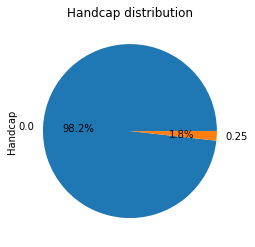

In [128]:
cleaned_df["Handcap"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Handcap distribution");

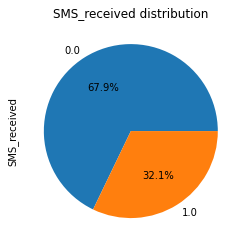

In [129]:
cleaned_df["SMS_received"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("SMS_received distribution");

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd697631f10>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd62903d160>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd629e974f0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd629e978b0>}

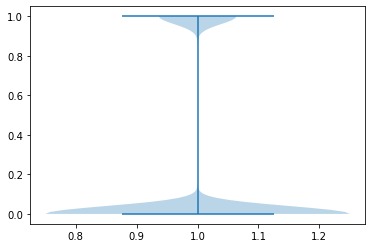

In [162]:
plt.violinplot(cleaned_df['No-show'])

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd697e59d00>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd629f58e20>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd629f86430>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd629f867f0>}

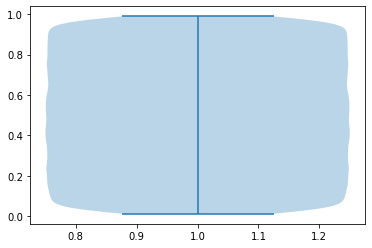

In [163]:
plt.violinplot(cleaned_df['ScheduledDay'])

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd697619ca0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd629e20580>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd697eab2e0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd697eab6a0>}

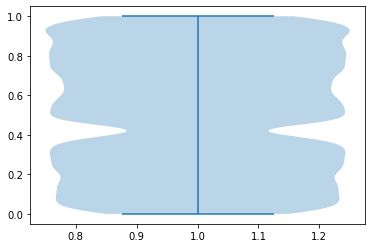

In [164]:
plt.violinplot(cleaned_df['AppointmentDay'])

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd697573a90>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd628ee0be0>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd628dd6190>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd628dd6550>}

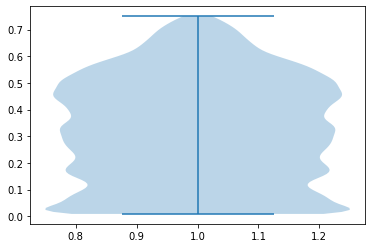

In [165]:
plt.violinplot(cleaned_df['Age'])

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd697f36490>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd697dbe5b0>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd697dbeb80>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd697dbef40>}

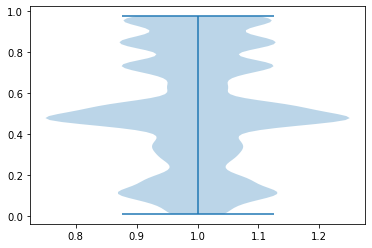

In [166]:
plt.violinplot(cleaned_df['Neighbourhood'])

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd6975da310>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd6975da2b0>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd6975da880>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd6975dac40>}

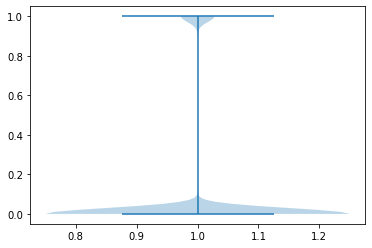

In [167]:
plt.violinplot(cleaned_df['Scholarship'])

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd629f33130>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd629f15f40>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd629f336a0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd629f33a60>}

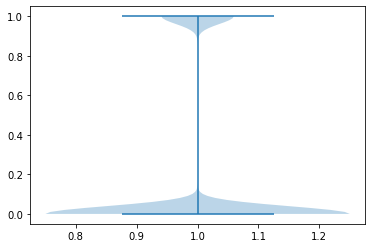

In [168]:
plt.violinplot(cleaned_df['Hipertension'])

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd633182580>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd629fd7a90>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd826348670>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd826348a30>}

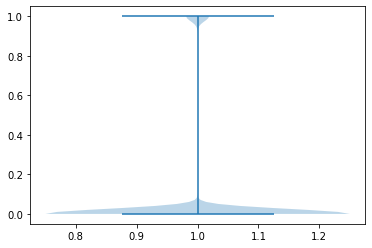

In [169]:
plt.violinplot(cleaned_df['Diabetes'])

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd632a717f0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd826367250>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd632a71eb0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd632a7c2b0>}

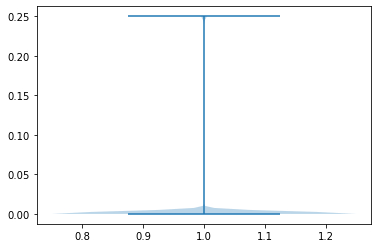

In [170]:
plt.violinplot(cleaned_df['Handcap'])

{'bodies': [<matplotlib.collections.PolyCollection at 0x7fd6978fafa0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7fd632a8b550>,
 'cmins': <matplotlib.collections.LineCollection at 0x7fd697904490>,
 'cbars': <matplotlib.collections.LineCollection at 0x7fd697904850>}

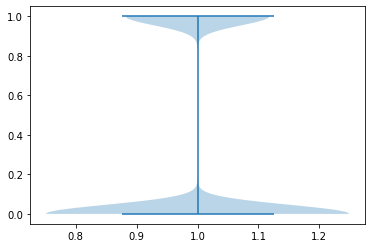

In [171]:
plt.violinplot(cleaned_df['SMS_received'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd6d42f2760>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd6d42f2d00>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd6d42f2490>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd6d42fe2e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd6d42fe5b0>],
 'means': []}

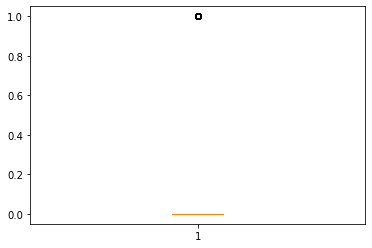

In [179]:
plt.boxplot(cleaned_df['No-show'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd81355e7f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd81355ed90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd81355e520>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd6d4309370>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd6d4309640>],
 'means': []}

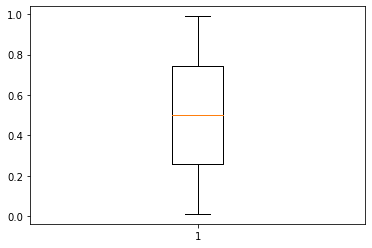

In [181]:
plt.boxplot(cleaned_df['ScheduledDay'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd7f0514880>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd7f0514e20>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd7f05145b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd7f051f400>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd7f051f6d0>],
 'means': []}

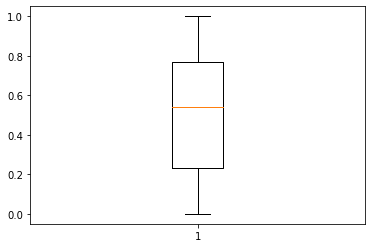

In [180]:
plt.boxplot(cleaned_df['AppointmentDay'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd81336bc40>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd813377220>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd81336b970>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd8133777c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd813377a90>],
 'means': []}

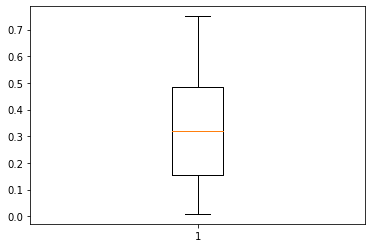

In [178]:
plt.boxplot(cleaned_df['Age'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd6d42acbb0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd6d42ba190>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd6d42ac8e0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd6d42ba730>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd6d42baa00>],
 'means': []}

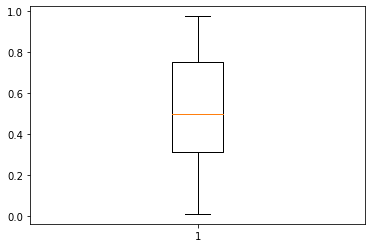

In [177]:
plt.boxplot(cleaned_df['Neighbourhood'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd629154ca0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd62915f280>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd6291549d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd62915f820>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd62915faf0>],
 'means': []}

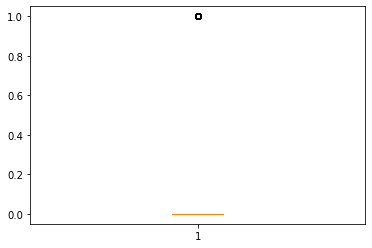

In [176]:
plt.boxplot(cleaned_df['Scholarship'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd6f413ea60>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd6f4148040>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd6f413e790>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd6f41485e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd6f41488b0>],
 'means': []}

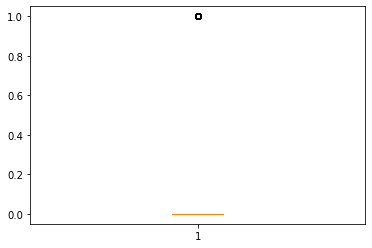

In [175]:
plt.boxplot(cleaned_df['Hipertension'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd6f3e9f9a0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd6f3e9ff40>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd6f3e9f6d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd6f3ea8520>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd6f3ea87f0>],
 'means': []}

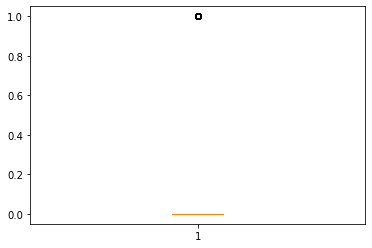

In [174]:
plt.boxplot(cleaned_df['Diabetes'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd6d3fd3ac0>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd6d3fdf0a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd6d3fc96d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd6d3fdf640>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd6d3fdf910>],
 'means': []}

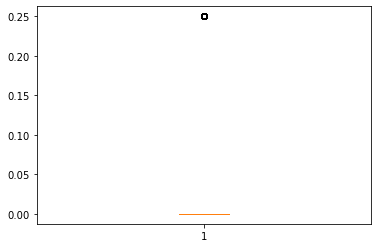

In [173]:
plt.boxplot(cleaned_df['Handcap'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fd629112a30>,
 'caps': [<matplotlib.lines.Line2D at 0x7fd629112fd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fd629112760>],
 'medians': [<matplotlib.lines.Line2D at 0x7fd6291205b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fd629120880>],
 'means': []}

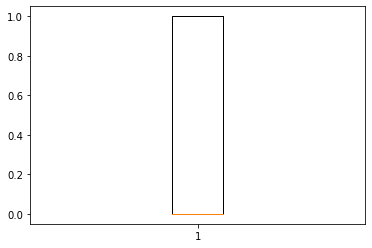

In [172]:
plt.boxplot(cleaned_df['SMS_received'])

In [161]:
cleaned_df.columns

Index(['ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship',
       'Hipertension', 'Diabetes', 'Handcap', 'SMS_received', 'No-show'],
      dtype='object')

In [130]:
fig = plt.figure(figsize=(36,36), dpi = 480)
sns.heatmap(cleaned_df.corr(), annot = True, fmt = '.2f')

<AxesSubplot:>

## Implementation of MLP Model using PyTorch

In [132]:
mlp = nn.Sequential(
            nn.Linear(9, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-4)

## Literature Review on Model Architectures and Techniques

The review of three given architectures, Deep, wide & deep and attention mechanism is available on my report but here I will try to implement deep and deep and wide architecture to have better idea about these architecture. 

### Deep Architecture 

In [137]:
dnn = nn.Sequential(
    nn.Linear(9, 256),
    nn.ReLU(),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

optimizer_dnn = torch.optim.Adam(dnn.parameters(), lr=1e-4)

### Wide & Deep Architecture

In [138]:
class DeepWideNN(nn.Module):
    def __init__(self):
        super(DeepWideNN, self).__init__()
        self.deep_path = nn.Sequential(
            nn.Linear(9, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        self.wide_path = nn.Sequential(
            nn.Linear(9, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )
        self.combine = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        out_deep = self.deep_path(x)
        out_wide = self.wide_path(x)
        combined_out = torch.cat((out_deep, out_wide), dim=1)
        out = self.combine(combined_out)
        return out

deep_wide_nn = DeepWideNN()
optimizer_deep_wide = torch.optim.Adam(deep_wide_nn.parameters(), lr=1e-4)

In [139]:
loss_function = nn.BCELoss()

In [189]:
def train_model(model, optimizer):
    train_losses, test_losses, validation_accuracy = [], [], []
    precision_scores, recall_scores, f1_scores = [], [], []
    for epoch in range(0,30):
        print(f'Starting Epoch {epoch+1}')
        current_loss = 0
        true_positives, false_positives, false_negatives = 0, 0, 0
        for features, labels in trainloader:
            features, labels = features.float(), labels.float()
            labels = labels.reshape(1, -1)
            optimizer.zero_grad()
            outputs = model(features)
            loss = loss_function(outputs, labels.reshape(-1, 1))
            loss.backward()

            optimizer.step()

            current_loss += (loss.item()*64)
        
        else: 
            test_loss = 0
            accuracy = 0
            with torch.no_grad():
                model.eval()
                correct_predictions = 0
                total_predictions = 0
                for features, labels in testloader:
                    features, labels = features.float(), labels.float()
                    labels = labels.reshape(-1, 1)
                    outputs = model(features)
                    loss = loss_function(outputs, labels)
                    test_loss += (loss.item()*64)
                    predictions = (outputs > 0.5).float()
                    correct_predictions += (predictions == labels).sum().item()
                    total_predictions += 64
                    true_positives += ((predictions == 1) & (labels == 1)).sum().item()
                    false_positives += ((predictions == 1) & (labels == 0)).sum().item()
                    false_negatives += ((predictions == 0) & (labels == 1)).sum().item()
                    
            precision = true_positives / (true_positives + false_positives + 1e-7)
            recall = true_positives / (true_positives + false_negatives + 1e-7)
            f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)
            accuracy = (correct_predictions / total_predictions) * 100
            model.train()
            train_losses.append(current_loss/len(train_dataset))
            test_losses.append(test_loss/len(test_dataset))
            validation_accuracy.append(accuracy)
            precision_scores.append(precision)
            recall_scores.append(recall)
            f1_scores.append(f1_score)
            print(f'Epoch {epoch+1} finished',
                      "Training loss: {:.3f}..".format(current_loss/len(trainloader)),
                      "Test loss: {:.3f}..".format(test_loss/len(testloader)),
                      "Test Accuracy: {:.3f}".format(accuracy),
                      "Precision: {:.3f}".format(precision),
                      "Recall: {:.3f}".format(recall),
                      "F1-score: {:.3f}".format(f1_score))

    print("Training has completed")
    return [train_losses, test_losses, validation_accuracy, precision_scores, recall_scores, f1_scores]

In [190]:
losses = train_model(mlp, optimizer)

Starting Epoch 1
Epoch 1 finished Training loss: 28.618.. Test loss: 29.035.. Test Accuracy: 79.265 Precision: 0.500 Recall: 0.014 F1-score: 0.028
Starting Epoch 2
Epoch 2 finished Training loss: 28.615.. Test loss: 29.010.. Test Accuracy: 79.232 Precision: 0.460 Recall: 0.009 F1-score: 0.018
Starting Epoch 3
Epoch 3 finished Training loss: 28.614.. Test loss: 29.162.. Test Accuracy: 79.298 Precision: 0.526 Recall: 0.016 F1-score: 0.032
Starting Epoch 4
Epoch 4 finished Training loss: 28.628.. Test loss: 29.007.. Test Accuracy: 79.242 Precision: 0.463 Recall: 0.007 F1-score: 0.014
Starting Epoch 5
Epoch 5 finished Training loss: 28.596.. Test loss: 29.075.. Test Accuracy: 79.293 Precision: 0.524 Recall: 0.015 F1-score: 0.029
Starting Epoch 6
Epoch 6 finished Training loss: 28.619.. Test loss: 28.980.. Test Accuracy: 79.275 Precision: 0.515 Recall: 0.008 F1-score: 0.015
Starting Epoch 7
Epoch 7 finished Training loss: 28.615.. Test loss: 29.086.. Test Accuracy: 79.275 Precision: 0.529 R

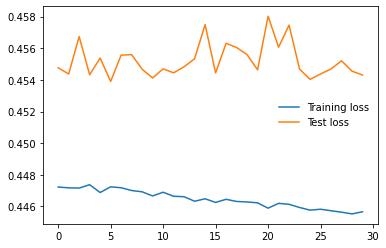

In [191]:
plt.plot(losses[0], label = "Training loss")
plt.plot(losses[1], label = "Test loss")
plt.legend(frameon = False)

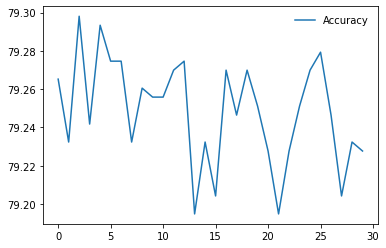

In [192]:
plt.plot(losses[2], label = "Accuracy")
plt.legend(frameon = False)

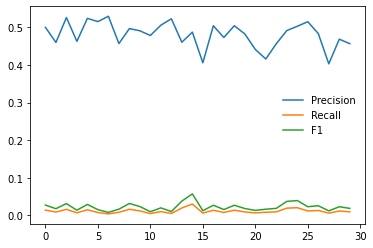

In [193]:
plt.plot(losses[3], label = "Precision")
plt.plot(losses[4], label = "Recall")
plt.plot(losses[5], label = "F1")
plt.legend(frameon = False)

In [194]:
losses_dnn = train_model(dnn, optimizer_dnn)

Starting Epoch 1
Epoch 1 finished Training loss: 28.532.. Test loss: 29.238.. Test Accuracy: 79.195 Precision: 0.429 Recall: 0.010 F1-score: 0.020
Starting Epoch 2
Epoch 2 finished Training loss: 28.534.. Test loss: 29.093.. Test Accuracy: 79.162 Precision: 0.413 Recall: 0.012 F1-score: 0.023
Starting Epoch 3
Epoch 3 finished Training loss: 28.517.. Test loss: 29.169.. Test Accuracy: 79.087 Precision: 0.422 Recall: 0.024 F1-score: 0.045
Starting Epoch 4
Epoch 4 finished Training loss: 28.517.. Test loss: 29.002.. Test Accuracy: 79.129 Precision: 0.391 Recall: 0.012 F1-score: 0.023
Starting Epoch 5
Epoch 5 finished Training loss: 28.523.. Test loss: 29.162.. Test Accuracy: 79.157 Precision: 0.425 Recall: 0.015 F1-score: 0.029
Starting Epoch 6
Epoch 6 finished Training loss: 28.494.. Test loss: 29.137.. Test Accuracy: 79.148 Precision: 0.419 Recall: 0.015 F1-score: 0.029
Starting Epoch 7
Epoch 7 finished Training loss: 28.476.. Test loss: 29.041.. Test Accuracy: 79.002 Precision: 0.411 R

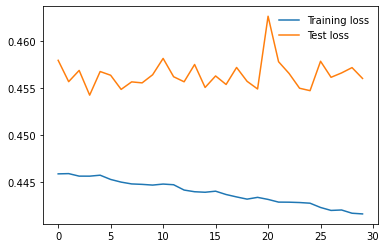

In [195]:
plt.plot(losses_dnn[0], label = "Training loss")
plt.plot(losses_dnn[1], label = "Test loss")
plt.legend(frameon = False)

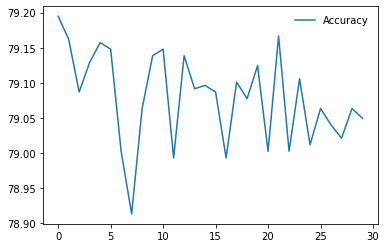

In [196]:
plt.plot(losses_dnn[2], label = "Accuracy")
plt.legend(frameon = False)

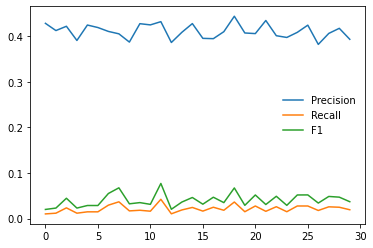

In [197]:
plt.plot(losses_dnn[3], label = "Precision")
plt.plot(losses_dnn[4], label = "Recall")
plt.plot(losses_dnn[5], label = "F1")
plt.legend(frameon = False)

In [198]:
wide_deep_losses = train_model(deep_wide_nn, optimizer_deep_wide)

Starting Epoch 1
Epoch 1 finished Training loss: 28.848.. Test loss: 29.153.. Test Accuracy: 79.279 Precision: 0.579 Recall: 0.003 F1-score: 0.005
Starting Epoch 2
Epoch 2 finished Training loss: 28.828.. Test loss: 29.049.. Test Accuracy: 79.293 Precision: 0.615 Recall: 0.004 F1-score: 0.007
Starting Epoch 3
Epoch 3 finished Training loss: 28.816.. Test loss: 29.305.. Test Accuracy: 79.284 Precision: 0.543 Recall: 0.006 F1-score: 0.011
Starting Epoch 4
Epoch 4 finished Training loss: 28.821.. Test loss: 29.449.. Test Accuracy: 79.256 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 5
Epoch 5 finished Training loss: 28.835.. Test loss: 29.104.. Test Accuracy: 79.265 Precision: 0.500 Recall: 0.000 F1-score: 0.001
Starting Epoch 6
Epoch 6 finished Training loss: 28.793.. Test loss: 29.152.. Test Accuracy: 79.275 Precision: 0.517 Recall: 0.007 F1-score: 0.014
Starting Epoch 7
Epoch 7 finished Training loss: 28.794.. Test loss: 29.059.. Test Accuracy: 79.279 Precision: 0.521 R

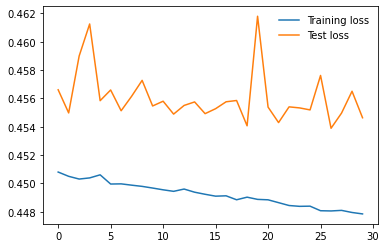

In [199]:
plt.plot(wide_deep_losses[0], label = "Training loss")
plt.plot(wide_deep_losses[1], label = "Test loss")
plt.legend(frameon = False)

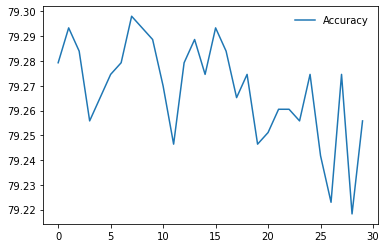

In [200]:
plt.plot(wide_deep_losses[2], label = "Accuracy")
plt.legend(frameon = False)

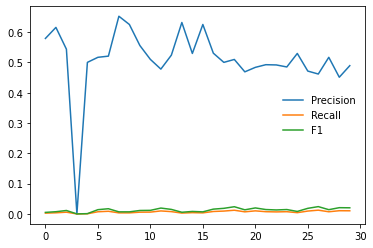

In [201]:
plt.plot(wide_deep_losses[3], label = "Precision")
plt.plot(wide_deep_losses[4], label = "Recall")
plt.plot(wide_deep_losses[5], label = "F1")
plt.legend(frameon = False)

## Experimentation with Activation Functions and Optimizers

In [202]:
mlp_tanh = nn.Sequential(
    nn.Linear(9, 256),
    nn.Tanh(),
    nn.Linear(256, 128),
    nn.Tanh(),
    nn.Linear(128, 64),
    nn.Tanh(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)
optimizer_mlp_tanh = torch.optim.Adam(mlp_tanh.parameters(), lr=1e-4)

In [203]:
losses_tanh = train_model(mlp_tanh, optimizer_mlp_tanh)

Starting Epoch 1
Epoch 1 finished Training loss: 31.091.. Test loss: 30.891.. Test Accuracy: 79.068 Precision: 0.358 Recall: 0.012 F1-score: 0.023
Starting Epoch 2
Epoch 2 finished Training loss: 30.552.. Test loss: 30.616.. Test Accuracy: 79.148 Precision: 0.430 Recall: 0.018 F1-score: 0.034
Starting Epoch 3
Epoch 3 finished Training loss: 30.281.. Test loss: 30.354.. Test Accuracy: 79.171 Precision: 0.400 Recall: 0.009 F1-score: 0.018
Starting Epoch 4
Epoch 4 finished Training loss: 29.984.. Test loss: 29.979.. Test Accuracy: 79.162 Precision: 0.440 Recall: 0.019 F1-score: 0.036
Starting Epoch 5
Epoch 5 finished Training loss: 29.728.. Test loss: 29.816.. Test Accuracy: 79.242 Precision: 0.462 Recall: 0.007 F1-score: 0.014
Starting Epoch 6
Epoch 6 finished Training loss: 29.563.. Test loss: 29.729.. Test Accuracy: 79.242 Precision: 0.455 Recall: 0.006 F1-score: 0.011
Starting Epoch 7
Epoch 7 finished Training loss: 29.457.. Test loss: 29.532.. Test Accuracy: 79.214 Precision: 0.442 R

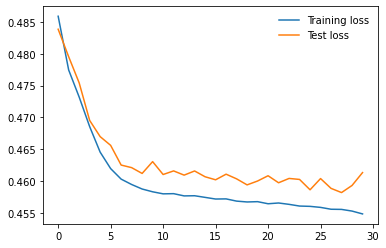

In [204]:
plt.plot(losses_tanh[0], label = "Training loss")
plt.plot(losses_tanh[1], label = "Test loss")
plt.legend(frameon = False)

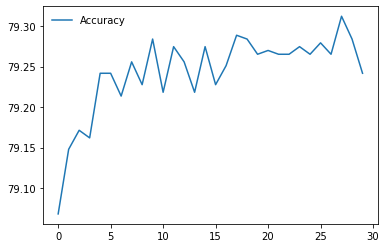

In [205]:
plt.plot(losses_tanh[2], label = "Accuracy")
plt.legend(frameon = False)

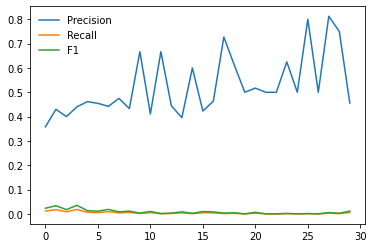

In [206]:
plt.plot(losses_tanh[3], label = "Precision")
plt.plot(losses_tanh[4], label = "Recall")
plt.plot(losses_tanh[5], label = "F1")
plt.legend(frameon = False)

In [256]:
class DeepWideNNTanh(nn.Module):
    def __init__(self):
        super(DeepWideNNTanh, self).__init__()
        self.deep_path = nn.Sequential(
            nn.Linear(9, 256),
            nn.Tanh(),
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh()
        )
        self.wide_path = nn.Sequential(
            nn.Linear(9, 32),
            nn.Tanh(),
            nn.Linear(32, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )
        self.combine = nn.Sequential(
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        out_deep = self.deep_path(x)
        out_wide = self.wide_path(x)
        combined_out = torch.cat((out_deep, out_wide), dim=1)
        out = self.combine(combined_out)
        return out

tanh_deep_wide_nn = DeepWideNNTanh()
optimizer_deep_wide_tanh = torch.optim.Adam(tanh_deep_wide_nn.parameters(), lr=1e-4)

In [257]:
losses_tanh_wide_deep_nn =  train_model(tanh_deep_wide_nn, optimizer_deep_wide_tanh )

Starting Epoch 1
Epoch 1 finished Training loss: 31.280.. Test loss: 30.864.. Test Accuracy: 78.482 Precision: 0.305 Recall: 0.030 F1-score: 0.055
Starting Epoch 2
Epoch 2 finished Training loss: 30.499.. Test loss: 30.600.. Test Accuracy: 79.002 Precision: 0.372 Recall: 0.019 F1-score: 0.035
Starting Epoch 3
Epoch 3 finished Training loss: 30.087.. Test loss: 30.032.. Test Accuracy: 79.124 Precision: 0.436 Recall: 0.023 F1-score: 0.044
Starting Epoch 4
Epoch 4 finished Training loss: 29.719.. Test loss: 29.701.. Test Accuracy: 79.265 Precision: 0.500 Recall: 0.009 F1-score: 0.018
Starting Epoch 5
Epoch 5 finished Training loss: 29.517.. Test loss: 29.685.. Test Accuracy: 79.153 Precision: 0.423 Recall: 0.015 F1-score: 0.029
Starting Epoch 6
Epoch 6 finished Training loss: 29.448.. Test loss: 29.586.. Test Accuracy: 79.251 Precision: 0.457 Recall: 0.004 F1-score: 0.007
Starting Epoch 7
Epoch 7 finished Training loss: 29.397.. Test loss: 29.495.. Test Accuracy: 79.200 Precision: 0.427 R

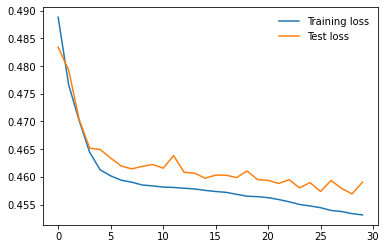

In [258]:
plt.plot(losses_tanh_wide_deep_nn[0], label = "Training loss")
plt.plot(losses_tanh_wide_deep_nn[1], label = "Test loss")
plt.legend(frameon = False)

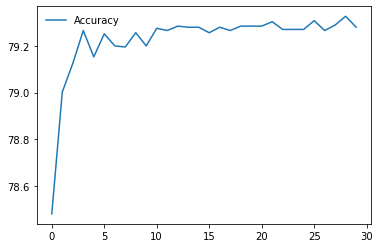

In [259]:
plt.plot(losses_tanh_wide_deep_nn[2], label = "Accuracy")
plt.legend(frameon = False)

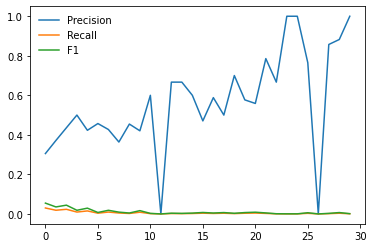

In [260]:
plt.plot(losses_tanh_wide_deep_nn[3], label = "Precision")
plt.plot(losses_tanh_wide_deep_nn[4], label = "Recall")
plt.plot(losses_tanh_wide_deep_nn[5], label = "F1")
plt.legend(frameon = False)

In [207]:
adagrad_optimizer = torch.optim.Adagrad(mlp.parameters(), lr=1e-4)

In [208]:
losses_adagrad = train_model(mlp, adagrad_optimizer)

Starting Epoch 1
Epoch 1 finished Training loss: 28.410.. Test loss: 28.957.. Test Accuracy: 79.251 Precision: 0.487 Recall: 0.013 F1-score: 0.025
Starting Epoch 2
Epoch 2 finished Training loss: 28.394.. Test loss: 28.988.. Test Accuracy: 79.265 Precision: 0.500 Recall: 0.014 F1-score: 0.026
Starting Epoch 3
Epoch 3 finished Training loss: 28.392.. Test loss: 28.984.. Test Accuracy: 79.261 Precision: 0.496 Recall: 0.014 F1-score: 0.027
Starting Epoch 4
Epoch 4 finished Training loss: 28.391.. Test loss: 28.980.. Test Accuracy: 79.256 Precision: 0.492 Recall: 0.014 F1-score: 0.026
Starting Epoch 5
Epoch 5 finished Training loss: 28.390.. Test loss: 29.004.. Test Accuracy: 79.261 Precision: 0.496 Recall: 0.014 F1-score: 0.026
Starting Epoch 6
Epoch 6 finished Training loss: 28.390.. Test loss: 28.960.. Test Accuracy: 79.256 Precision: 0.492 Recall: 0.014 F1-score: 0.026
Starting Epoch 7
Epoch 7 finished Training loss: 28.388.. Test loss: 28.985.. Test Accuracy: 79.256 Precision: 0.492 R

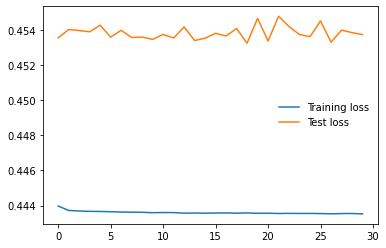

In [209]:
plt.plot(losses_adagrad[0], label = "Training loss")
plt.plot(losses_adagrad[1], label = "Test loss")
plt.legend(frameon = False)

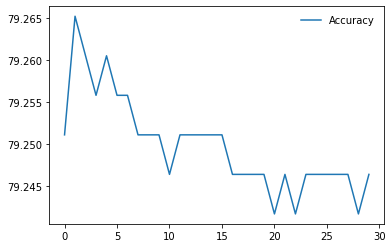

In [210]:
plt.plot(losses_adagrad[2], label = "Accuracy")
plt.legend(frameon = False)

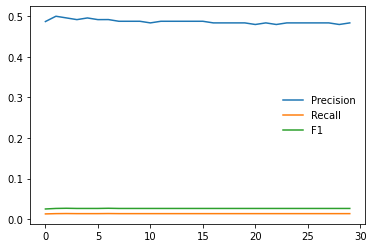

In [211]:
plt.plot(losses_adagrad[3], label = "Precision")
plt.plot(losses_adagrad[4], label = "Recall")
plt.plot(losses_adagrad[5], label = "F1")
plt.legend(frameon = False)

In [212]:
SGD_optimizer = torch.optim.SGD(mlp.parameters(), lr=1e-4)

In [213]:
losses_SGD = train_model(mlp, SGD_optimizer)

Starting Epoch 1
Epoch 1 finished Training loss: 28.385.. Test loss: 29.041.. Test Accuracy: 79.246 Precision: 0.484 Recall: 0.014 F1-score: 0.026
Starting Epoch 2
Epoch 2 finished Training loss: 28.384.. Test loss: 28.944.. Test Accuracy: 79.246 Precision: 0.484 Recall: 0.014 F1-score: 0.026
Starting Epoch 3
Epoch 3 finished Training loss: 28.384.. Test loss: 29.047.. Test Accuracy: 79.246 Precision: 0.484 Recall: 0.014 F1-score: 0.026
Starting Epoch 4
Epoch 4 finished Training loss: 28.384.. Test loss: 28.988.. Test Accuracy: 79.246 Precision: 0.484 Recall: 0.014 F1-score: 0.026
Starting Epoch 5
Epoch 5 finished Training loss: 28.382.. Test loss: 29.040.. Test Accuracy: 79.246 Precision: 0.484 Recall: 0.014 F1-score: 0.026
Starting Epoch 6
Epoch 6 finished Training loss: 28.384.. Test loss: 28.981.. Test Accuracy: 79.237 Precision: 0.476 Recall: 0.014 F1-score: 0.026
Starting Epoch 7
Epoch 7 finished Training loss: 28.383.. Test loss: 28.967.. Test Accuracy: 79.237 Precision: 0.476 R

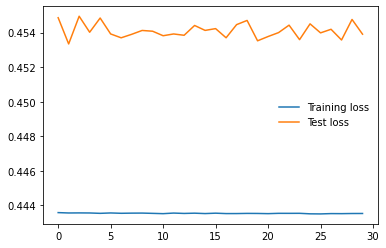

In [214]:
plt.plot(losses_SGD[0], label = "Training loss")
plt.plot(losses_SGD[1], label = "Test loss")
plt.legend(frameon = False)

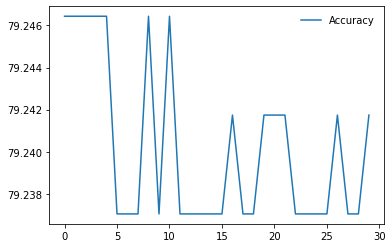

In [215]:
plt.plot(losses_SGD[2], label = "Accuracy")
plt.legend(frameon = False)

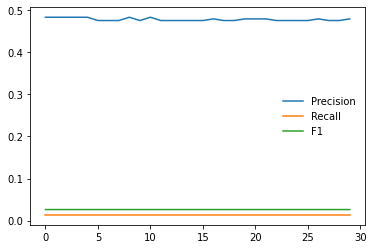

In [216]:
plt.plot(losses_SGD[3], label = "Precision")
plt.plot(losses_SGD[4], label = "Recall")
plt.plot(losses_SGD[5], label = "F1")
plt.legend(frameon = False)

## Regularization Techniques and Hyperparameter Tuning

### Dropout

In [217]:
mlp_dropout = nn.Sequential(
            nn.Linear(9, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
optimizer_dropout = torch.optim.Adam(mlp_dropout.parameters(), lr=1e-4)

In [218]:
losses_dropout = train_model(mlp_dropout, optimizer_dropout)

Starting Epoch 1
Epoch 1 finished Training loss: 31.808.. Test loss: 30.611.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 2
Epoch 2 finished Training loss: 30.421.. Test loss: 30.214.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 3
Epoch 3 finished Training loss: 30.165.. Test loss: 29.982.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 4
Epoch 4 finished Training loss: 30.045.. Test loss: 29.864.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 5
Epoch 5 finished Training loss: 29.962.. Test loss: 29.754.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 6
Epoch 6 finished Training loss: 29.846.. Test loss: 29.764.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 7
Epoch 7 finished Training loss: 29.851.. Test loss: 29.675.. Test Accuracy: 79.265 Precision: 0.000 R

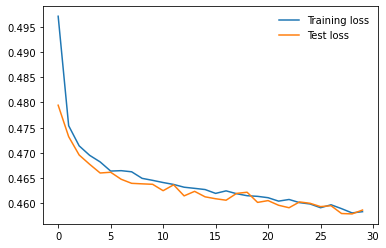

In [219]:
plt.plot(losses_dropout[0], label = "Training loss")
plt.plot(losses_dropout[1], label = "Test loss")
plt.legend(frameon = False)

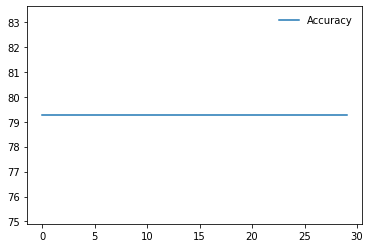

In [220]:
plt.plot(losses_dropout[2], label = "Accuracy")
plt.legend(frameon = False)

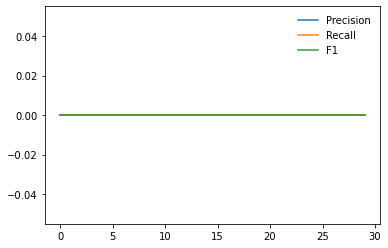

In [221]:
plt.plot(losses_dropout[3], label = "Precision")
plt.plot(losses_dropout[4], label = "Recall")
plt.plot(losses_dropout[5], label = "F1")
plt.legend(frameon = False)

In [222]:
mlp_dropout_tanh = nn.Sequential(
            nn.Linear(9, 256),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
optimizer_dropout_tanh = torch.optim.Adam(mlp_dropout_tanh.parameters(), lr=1e-4)

In [223]:
losses_dropout_tanh = train_model(mlp_dropout_tanh, optimizer_dropout_tanh)

Starting Epoch 1
Epoch 1 finished Training loss: 31.269.. Test loss: 31.005.. Test Accuracy: 79.265 Precision: 0.500 Recall: 0.004 F1-score: 0.008
Starting Epoch 2
Epoch 2 finished Training loss: 30.801.. Test loss: 30.812.. Test Accuracy: 78.866 Precision: 0.322 Recall: 0.018 F1-score: 0.033
Starting Epoch 3
Epoch 3 finished Training loss: 30.752.. Test loss: 30.759.. Test Accuracy: 78.946 Precision: 0.343 Recall: 0.017 F1-score: 0.032
Starting Epoch 4
Epoch 4 finished Training loss: 30.677.. Test loss: 30.917.. Test Accuracy: 79.270 Precision: 0.524 Recall: 0.003 F1-score: 0.005
Starting Epoch 5
Epoch 5 finished Training loss: 30.586.. Test loss: 30.529.. Test Accuracy: 79.054 Precision: 0.367 Recall: 0.014 F1-score: 0.027
Starting Epoch 6
Epoch 6 finished Training loss: 30.451.. Test loss: 30.332.. Test Accuracy: 79.063 Precision: 0.411 Recall: 0.023 F1-score: 0.043
Starting Epoch 7
Epoch 7 finished Training loss: 30.347.. Test loss: 30.276.. Test Accuracy: 78.927 Precision: 0.399 R

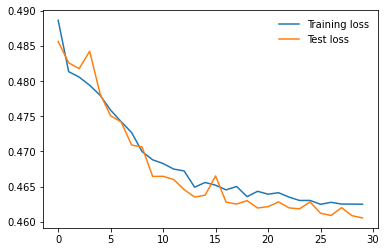

In [224]:
plt.plot(losses_dropout_tanh[0], label = "Training loss")
plt.plot(losses_dropout_tanh[1], label = "Test loss")
plt.legend(frameon = False)

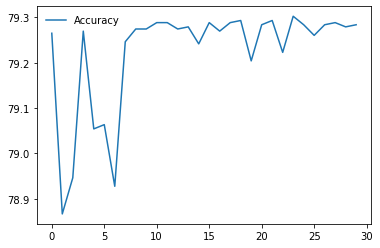

In [225]:
plt.plot(losses_dropout_tanh[2], label = "Accuracy")
plt.legend(frameon = False)

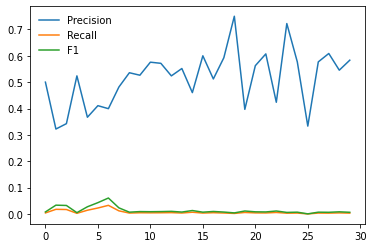

In [226]:
plt.plot(losses_dropout_tanh[3], label = "Precision")
plt.plot(losses_dropout_tanh[4], label = "Recall")
plt.plot(losses_dropout_tanh[5], label = "F1")
plt.legend(frameon = False)

### L2 Regularization

In [230]:
def train_model_L2(model, optimizer, alpha):
    train_losses, test_losses, validation_accuracy = [], [], []
    precision_scores, recall_scores, f1_scores = [], [], []
    for epoch in range(0,30):
        print(f'Starting Epoch {epoch+1}')
        current_loss = 0
        true_positives, false_positives, false_negatives = 0, 0, 0
        for features, labels in trainloader:
            features, labels = features.float(), labels.float()
            labels = labels.reshape(1, -1)
            optimizer.zero_grad()
            L2_regularization = None
            for i in model.named_parameters():
                if L2_regularization is None:
                      L2_regularization = torch.sum(i[1].norm(2) ** 2)
                else:
                      L2_regularization += torch.sum(i[1].norm(2) ** 2)
            outputs = model(features)
            loss = loss_function(outputs, labels.reshape(-1, 1))
            loss += alpha * L2_regularization
            loss.backward()

            optimizer.step()

            current_loss += (loss.item()*64)
        
        else: 
            test_loss = 0
            accuracy = 0
            with torch.no_grad():
                model.eval()
                correct_predictions = 0
                total_predictions = 0
                for features, labels in testloader:
                    features, labels = features.float(), labels.float()
                    labels = labels.reshape(-1, 1)
                    outputs = model(features)
                    loss = loss_function(outputs, labels)
                    test_loss += (loss.item()*64)
                    predictions = (outputs > 0.5).float()
                    correct_predictions += (predictions == labels).sum().item()
                    total_predictions += 64
                    true_positives += ((predictions == 1) & (labels == 1)).sum().item()
                    false_positives += ((predictions == 1) & (labels == 0)).sum().item()
                    false_negatives += ((predictions == 0) & (labels == 1)).sum().item()
                    
            precision = true_positives / (true_positives + false_positives + 1e-7)
            recall = true_positives / (true_positives + false_negatives + 1e-7)
            f1_score = 2 * (precision * recall) / (precision + recall + 1e-7)
            accuracy = (correct_predictions / total_predictions) * 100
            model.train()
            train_losses.append(current_loss/len(train_dataset))
            test_losses.append(test_loss/len(test_dataset))
            validation_accuracy.append(accuracy)
            precision_scores.append(precision)
            recall_scores.append(recall)
            f1_scores.append(f1_score)
            print(f'Epoch {epoch+1} finished',
                      "Training loss: {:.3f}..".format(current_loss/len(trainloader)),
                      "Test loss: {:.3f}..".format(test_loss/len(testloader)),
                      "Test Accuracy: {:.3f}".format(accuracy),
                      "Precision: {:.3f}".format(precision),
                      "Recall: {:.3f}".format(recall),
                      "F1-score: {:.3f}".format(f1_score))

    print("Training has completed")
    return [train_losses, test_losses, validation_accuracy, precision_scores, recall_scores, f1_scores]

In [231]:
l2_losses = train_model_L2(mlp_tanh, optimizer_mlp_tanh, 0.0001)

Starting Epoch 1
Epoch 1 finished Training loss: 30.534.. Test loss: 29.350.. Test Accuracy: 79.289 Precision: 0.727 Recall: 0.002 F1-score: 0.004
Starting Epoch 2
Epoch 2 finished Training loss: 30.441.. Test loss: 29.274.. Test Accuracy: 79.284 Precision: 0.750 Recall: 0.001 F1-score: 0.003
Starting Epoch 3
Epoch 3 finished Training loss: 30.364.. Test loss: 29.297.. Test Accuracy: 79.307 Precision: 0.667 Recall: 0.004 F1-score: 0.008
Starting Epoch 4
Epoch 4 finished Training loss: 30.306.. Test loss: 29.327.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 5
Epoch 5 finished Training loss: 30.249.. Test loss: 29.254.. Test Accuracy: 79.307 Precision: 0.737 Recall: 0.003 F1-score: 0.006
Starting Epoch 6
Epoch 6 finished Training loss: 30.212.. Test loss: 29.310.. Test Accuracy: 79.303 Precision: 0.682 Recall: 0.003 F1-score: 0.007
Starting Epoch 7
Epoch 7 finished Training loss: 30.168.. Test loss: 29.313.. Test Accuracy: 79.289 Precision: 0.667 R

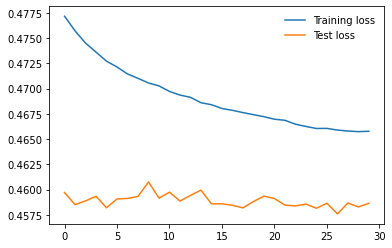

In [232]:
plt.plot(l2_losses[0], label = "Training loss")
plt.plot(l2_losses[1], label = "Test loss")
plt.legend(frameon = False)

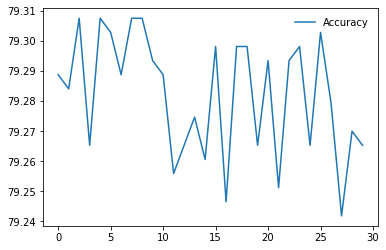

In [233]:
plt.plot(l2_losses[2], label = "Accuracy")
plt.legend(frameon = False)

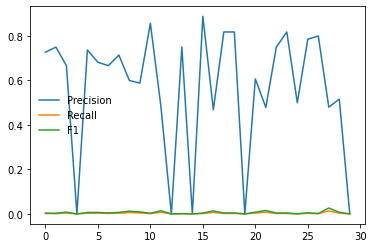

In [234]:
plt.plot(l2_losses[3], label = "Precision")
plt.plot(l2_losses[4], label = "Recall")
plt.plot(l2_losses[5], label = "F1")
plt.legend(frameon = False)

In [235]:
l2_losses_relu = train_model_L2(mlp, optimizer, 0.0001)

Starting Epoch 1
Epoch 1 finished Training loss: 29.843.. Test loss: 29.158.. Test Accuracy: 79.270 Precision: 0.503 Recall: 0.018 F1-score: 0.034
Starting Epoch 2
Epoch 2 finished Training loss: 29.689.. Test loss: 29.026.. Test Accuracy: 79.265 Precision: 0.500 Recall: 0.005 F1-score: 0.010
Starting Epoch 3
Epoch 3 finished Training loss: 29.600.. Test loss: 29.069.. Test Accuracy: 79.246 Precision: 0.452 Recall: 0.004 F1-score: 0.009
Starting Epoch 4
Epoch 4 finished Training loss: 29.566.. Test loss: 28.976.. Test Accuracy: 79.228 Precision: 0.441 Recall: 0.007 F1-score: 0.014
Starting Epoch 5
Epoch 5 finished Training loss: 29.527.. Test loss: 29.022.. Test Accuracy: 79.242 Precision: 0.449 Recall: 0.005 F1-score: 0.010
Starting Epoch 6
Epoch 6 finished Training loss: 29.515.. Test loss: 29.111.. Test Accuracy: 79.232 Precision: 0.451 Recall: 0.007 F1-score: 0.014
Starting Epoch 7
Epoch 7 finished Training loss: 29.478.. Test loss: 28.996.. Test Accuracy: 79.251 Precision: 0.481 R

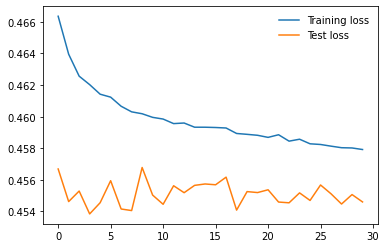

In [236]:
plt.plot(l2_losses_relu[0], label = "Training loss")
plt.plot(l2_losses_relu[1], label = "Test loss")
plt.legend(frameon = False)

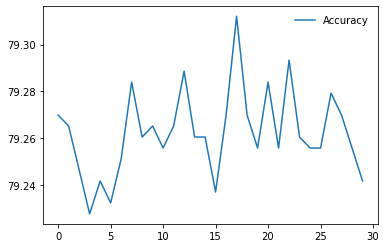

In [237]:
plt.plot(l2_losses_relu[2], label = "Accuracy")
plt.legend(frameon = False)

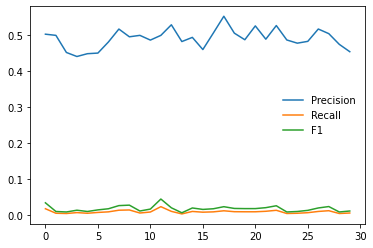

In [238]:
plt.plot(l2_losses_relu[3], label = "Precision")
plt.plot(l2_losses_relu[4], label = "Recall")
plt.plot(l2_losses_relu[5], label = "F1")
plt.legend(frameon = False)

In [261]:
losses_wide_deep_tanh_l2 = train_model_L2(tanh_deep_wide_nn, optimizer_deep_wide_tanh, 0.0001)

Starting Epoch 1
Epoch 1 finished Training loss: 30.998.. Test loss: 29.307.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 2
Epoch 2 finished Training loss: 30.825.. Test loss: 29.196.. Test Accuracy: 79.289 Precision: 0.551 Recall: 0.006 F1-score: 0.012
Starting Epoch 3
Epoch 3 finished Training loss: 30.688.. Test loss: 29.280.. Test Accuracy: 79.303 Precision: 0.900 Recall: 0.002 F1-score: 0.004
Starting Epoch 4
Epoch 4 finished Training loss: 30.576.. Test loss: 29.344.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 5
Epoch 5 finished Training loss: 30.486.. Test loss: 29.199.. Test Accuracy: 79.265 Precision: 0.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 6
Epoch 6 finished Training loss: 30.418.. Test loss: 29.209.. Test Accuracy: 79.270 Precision: 1.000 Recall: 0.000 F1-score: 0.000
Starting Epoch 7
Epoch 7 finished Training loss: 30.364.. Test loss: 29.146.. Test Accuracy: 79.275 Precision: 1.000 R

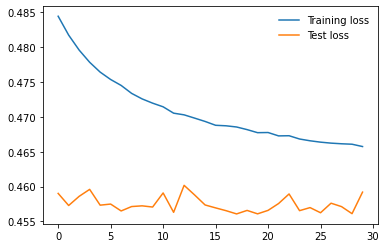

In [262]:
plt.plot(losses_wide_deep_tanh_l2[0], label = "Training loss")
plt.plot(losses_wide_deep_tanh_l2[1], label = "Test loss")
plt.legend(frameon = False)

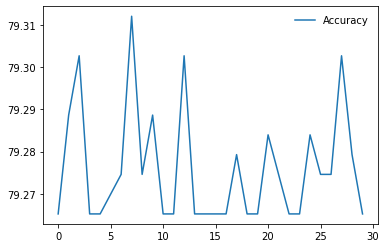

In [263]:
plt.plot(losses_wide_deep_tanh_l2[2], label = "Accuracy")
plt.legend(frameon = False)

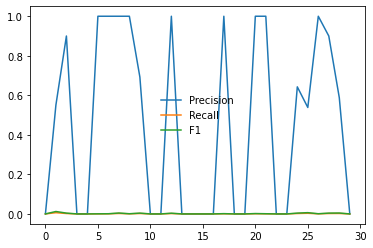

In [264]:
plt.plot(losses_wide_deep_tanh_l2[3], label = "Precision")
plt.plot(losses_wide_deep_tanh_l2[4], label = "Recall")
plt.plot(losses_wide_deep_tanh_l2[5], label = "F1")
plt.legend(frameon = False)